In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import os
import shutil
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'

In [4]:

from sklearn.model_selection import train_test_split


zip_file_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'
extracted_dir = '/content/RiceLeafsDisease'
output_dir = '/content/organized_dataset'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


print("Extracted directory structure:")
for root, dirs, files in os.walk(extracted_dir):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)
    print("-" * 40)

for split in ['train', 'validation', 'test']:
    for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

images = []
labels = []

for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
    class_dir = None
    for root, dirs, files in os.walk(extracted_dir):
        if class_name in dirs:
            class_dir = os.path.join(root, class_name)
            break

    if class_dir is None:
        print(f"Warning: Directory for class '{class_name}' not found. Skipping...")
        continue

    for img in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img)
        if os.path.isfile(img_path):
            images.append(img_path)
            labels.append(class_name)

print(f"Total images found: {len(images)}")

if len(images) == 0:
    raise ValueError("No images found in the dataset. Please check the dataset structure.")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

def move_images(image_list, labels_list, split):
    for img, label in zip(image_list, labels_list):
        dest_dir = os.path.join(output_dir, split, label)
        shutil.copy(img, dest_dir)

move_images(train_images, train_labels, 'train')
move_images(val_images, val_labels, 'validation')
move_images(test_images, test_labels, 'test')

print("Data has been organized successfully.")
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Extracted directory structure:
Root: /content/RiceLeafsDisease
Directories: ['RiceLeafsDisease']
Files: []
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease
Directories: ['healthy', 'leaf_blast', 'leaf_scald', 'bacterial_leaf_blight']
Files: ['desktop.ini']
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease/healthy
Directories: []
Files: ['healthy (75).jpg', 'healthy (348).jpg', 'healthy (297).jpg', 'healthy (62).jpg', 'healthy (299).jpg', 'healthy (254).jpg', 'healthy (282).jpg', 'healthy (189).jpg', 'healthy (230).jpg', 'healthy (202).jpg', 'healthy (268).jpg', 'healthy (109).jpg', 'healthy (110).jpg', 'healthy (166).jpg', 'healthy (57).jpg', 'healthy (247).jpg', 'healthy (263).jpg', 'healthy (143).jpg', 'healthy (83).jpg', 'healthy (30).jpg', 'healthy (65).jpg', 'healthy (182).jpg', 'healthy (25).jpg', 'healthy (215).jpg', 'healthy (153).jpg', 'healthy (52).jpg', 'healthy (271).jpg', 'healthy (67).jpg', '

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'validation')

datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


test_dir = os.path.join(output_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1376 images belonging to 4 classes.
Found 295 images belonging to 4 classes.
Found 296 images belonging to 4 classes.


In [12]:


base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


<ipython-input-12-658b0b0e977e>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


In [13]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5483 - loss: 4.5385 - val_accuracy: 0.7729 - val_loss: 0.5928
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7249 - loss: 0.6311 - val_accuracy: 0.7966 - val_loss: 0.4876
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7493 - loss: 0.5218 - val_accuracy: 0.8305 - val_loss: 0.4339
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7631 - loss: 0.5024 - val_accuracy: 0.8339 - val_loss: 0.4544
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8057 - loss: 0.4122 - val_accuracy: 0.7966 - val_loss: 0.4504
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8212 - loss: 0.3837 - val_accuracy: 0.8407 - val_loss: 0.4022
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8028 - loss: 0.4344 - val_accuracy: 0.8780 - val_loss: 0.3632
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8298 - loss: 0.3672 - val_accuracy: 0.8746 - val_loss:

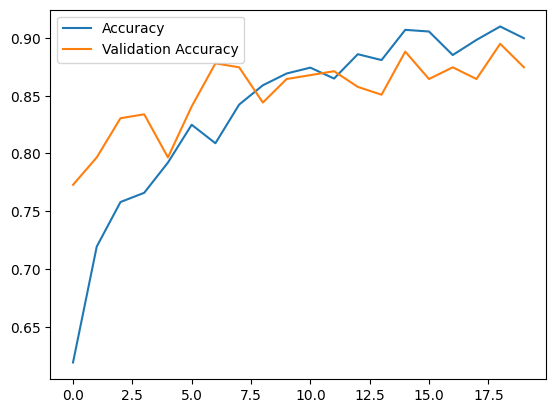

In [14]:


plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 941ms/step - accuracy: 0.8726 - loss: 0.3666
Test Accuracy: 90.20%


In [16]:
# Save the trained model
model.save('/content/rice_disease_model.h5')
print("Model saved as rice_disease_model.h5")


Model saved as rice_disease_model.h5


In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/organized_dataset/test/leaf_blast/Leaf_blast  (1157).jpg'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)
class_index = np.argmax(predictions)
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[class_index]

print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: leaf_blast


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


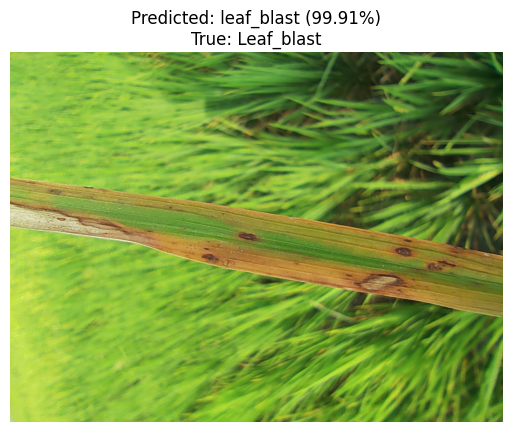

In [22]:
from tensorflow.keras.preprocessing import image

def visualize_prediction(img_path, model, class_labels, true_label=None):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))  # Match your model's input size
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100


    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\n"
              f"True: {true_label if true_label else 'Unknown'}", fontsize=12)
    plt.show()

# Example usage
img_path = '/content/organized_dataset/test/leaf_blast/Leaf_blast  (1157).jpg'
visualize_prediction(img_path, model, list(train_generator.class_indices.keys()), true_label)
